# EN 3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering
### Index No. - 230013A

# Question 1

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def intensity_transform(im, xp, fp):
    """Builds a lookup table according to break points and applies the lut to the image"""
    lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)
    transformed_image = transformed_image = cv.LUT(im, lut)
    return transformed_image

im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

xp = [0, 50, 50, 150, 150, 255]
fp = [0, 50, 100, 255, 150, 255]

transformed_image = intensity_transform(im, xp, fp)


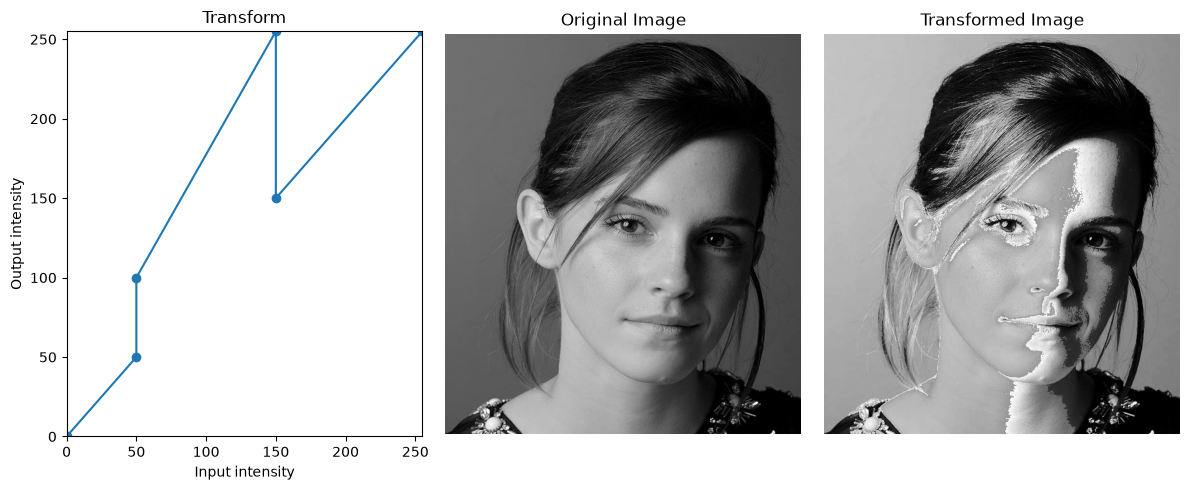

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(xp, fp, 'o-')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_title("Transform")

axes[1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(transformed_image, cmap='gray', vmin=0, vmax=255)
axes[2].axis('off')
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

At first, the transformation given in Fig. 1a was used, which had abrupt jumps at intensities of 50 and 150, and therefore resulted in discontinuous inversions in mid-tone values.

In [13]:
# For a visually pleasing output
xp = [0, 50, 100, 150, 200, 255]
fp = [0, 30, 100, 150, 255, 255]

transformed_image = intensity_transform(im, xp, fp)

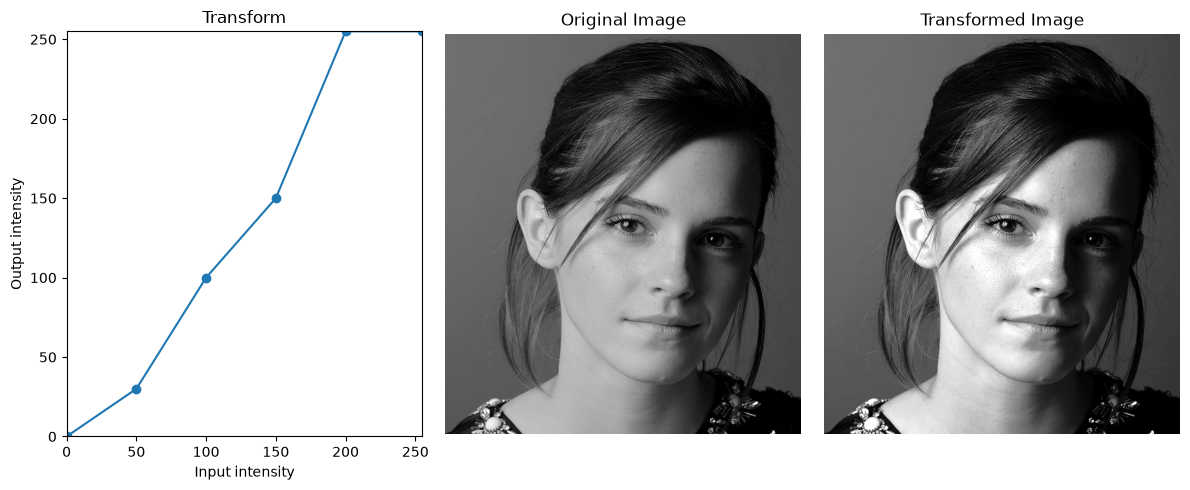

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(xp, fp, 'o-')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_title("Transform")

axes[1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(transformed_image, cmap='gray', vmin=0, vmax=255)
axes[2].axis('off')
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

After consulting the histogram of the image, the transform was altered to compress both higher and lower intensity values, which resulted in a visually pleasing contrast enhancement on the image.

# Question 2

In [51]:
im = cv.imread("images/q2.jpeg")

#Transformation for white matter
xp_wm = [0, 100, 140, 150, 160, 170, 180, 190, 220, 255]
fp_wm = [0,   0,   0,   0,   0,  30,  62, 150, 255, 255]
#Transformation for gray matter
xp_gm = [0, 100, 140, 150, 160, 170, 180, 190, 200, 255]
fp_gm = [0,   0,   0,   0,  66, 121, 182, 255, 255, 255]

transformed_image_wm = intensity_transform(im, xp_wm, fp_wm)
transformed_image_gm = intensity_transform(im, xp_gm, fp_gm)

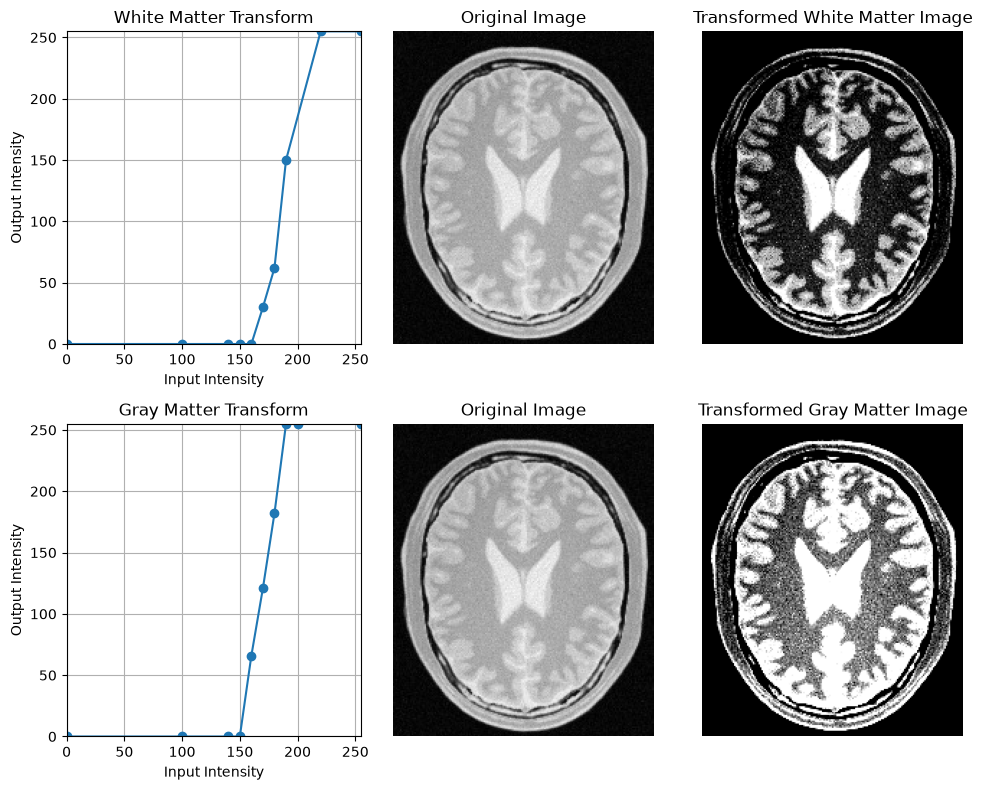

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))

axes[0][0].plot(xp_wm, fp_wm, 'o-')
axes[0][0].set_xlim(0, 255)
axes[0][0].set_ylim(0, 255)
axes[0][0].grid(True)
axes[0][0].set_xlabel("Input Intensity")
axes[0][0].set_ylabel("Output Intensity")
axes[0][0].set_title("White Matter Transform")

axes[0][1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[0][2].imshow(transformed_image_wm, cmap='gray', vmin=0, vmax=255)
axes[0][2].axis('off')
axes[0][2].set_title("Transformed White Matter Image")

axes[1][0].plot(xp_gm, fp_gm, 'o-')
axes[1][0].set_xlim(0, 255)
axes[1][0].set_ylim(0, 255)
axes[1][0].grid(True)
axes[1][0].set_xlabel("Input Intensity")
axes[1][0].set_ylabel("Output Intensity")
axes[1][0].set_title("Gray Matter Transform")

axes[1][1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[1][1].axis('off')
axes[1][1].set_title("Original Image")

axes[1][2].imshow(transformed_image_gm, cmap='gray', vmin=0, vmax=255)
axes[1][2].axis('off')
axes[1][2].set_title("Transformed Gray Matter Image")

plt.tight_layout()
plt.show()

The same piecewise-linear transformation approach from Q1 was applied here, and two separate transforms were used for gray matter (boundary) and white matter (middle) separately. At first, different pixel values were samples using a color picker to approximate the boundaries of gray and white matter. Later, a slider based approach was utilized to find the transformations best suited for each image. For the white matter image, the middle area was to be accentuated, so it has a steeper slope at 160-220, whereas for the gray matter image, the boundary areas had to be emphasized, so it was given a steeper slope at 150-190 (compressing background and increasing bright areas for better contrast).

# Question 3

In [56]:
def gamma_correct(im, gamma):
    lut = np.array([((i/255.0)**gamma)*255 for i in np.arange(0, 256)]).astype("uint8")
    return cv.LUT(im, lut)

im = cv.imread("images/q3.jpeg")
im_lab = cv.cvtColor(im, cv.COLOR_BGR2LAB) # L-illumination | a,b-color space
l_channel, a_channel, b_channel = cv.split(im_lab) # Image is split into L, a and b channels.

gamma = 0.65 # Gamma value
gamma_corrected_l = gamma_correct(l_channel, gamma)
reconstructed_im_lab = cv.merge([gamma_corrected_l, a_channel, b_channel])

# Histograms
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
hist = cv.calcHist([im_rgb], [0], None, [256], [0,256])
reconstructed_im_rgb = cv.cvtColor(reconstructed_im_lab, cv.COLOR_LAB2RGB)
gamma_hist = cv.calcHist([reconstructed_im_rgb], [0], None, [256], [0,256])

Text(0.5, 1.0, 'Corrected Image')

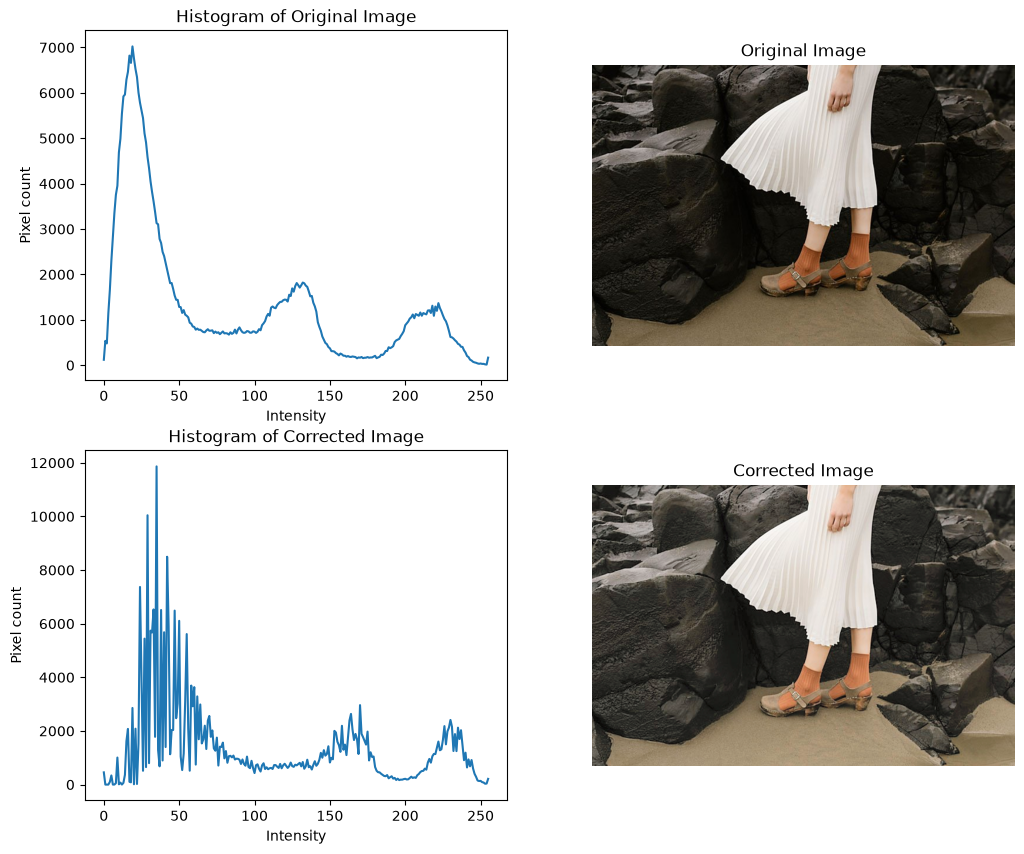

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of Original Image")

axes[0][1].imshow(im_rgb)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(gamma_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Corrected Image")

axes[1][1].imshow(reconstructed_im_rgb)
axes[1][1].axis('off')
axes[1][1].set_title("Corrected Image")

The image was separated into L,a,b channels and the L plane was gamma corrected with a gamma value of 0.65 (Because the original image had too dark shadows, gamma should be < 1). The gamma corrected image has more visible shadows (dark areas), and this is evident from the histogram, which has moved right, giving higher pixel counts to higher intensities.

# Question 4

In [58]:
def vibrance_transform(i, a, sigma):
    f_inter = i + a*128*np.exp(-(i-128)**2/(2*sigma**2))
    f = min(f_inter, 255)
    return f

im = cv.imread("images/q4.jpeg")
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
hue, saturation, value = cv.split(im_hsv)

a = 0.8 # a value
sigma = 70

lut = np.array([vibrance_transform(i, a, sigma) for i in np.arange(0, 256)]).astype("uint8")
im_sat_tform = cv.LUT(saturation, lut)

vibr_hsv = cv.merge([hue, im_sat_tform, value]) # Three planes are recombined.

Text(0.5, 1.0, 'Vibrance Transformed Image')

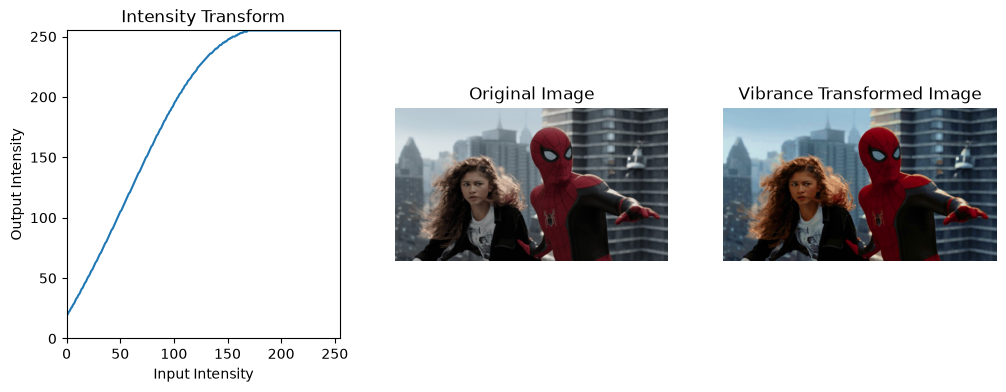

In [59]:
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
vibr_rgb = cv.cvtColor(vibr_hsv, cv.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(np.arange(256), lut)
axes[0].set_xlim(0,255)
axes[0].set_ylim(0,255)
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_title("Intensity Transform")

axes[1].imshow(im_rgb)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(vibr_rgb)
axes[2].axis('off')
axes[2].set_title("Vibrance Transformed Image")

Intensity transform f(x) = min(i + a x 128 x exp(-(i-128)^2/(2 x sigma^2)), 255) was applied to the saturation plane of the image. At sigma = 70, the value of 'a' was chosen to be 0.8 to give a more visually pleasing result. As seen in the intensity transformation plot, the transform behaves like a boosted near-linear curve that saturates to 255 at higher input saturations. The result is, the overall vibrance of the image is increased, while keeping skin tones and other less saturated areas at a reasonable level.

# Question 5

In [60]:
im = cv.imread("images/shells.tif", cv.IMREAD_GRAYSCALE)
old_hist = cv.calcHist([im], [0], None, [256], [0,256])

def histogram_equalizer(im, hist):
    cdf = np.cumsum(old_hist)
    cdf_min = cdf[cdf > 0].min()
    lut = np.round((cdf-cdf_min) / (im.size-cdf_min) * 255).astype(np.uint8)
    lut = np.clip(lut, 0, 255)
    equalized_image = cv.LUT(im, lut)
    return equalized_image

equalized_image = histogram_equalizer(im, old_hist)
new_hist = cv.calcHist([equalized_image], [0], None, [256], [0,256])

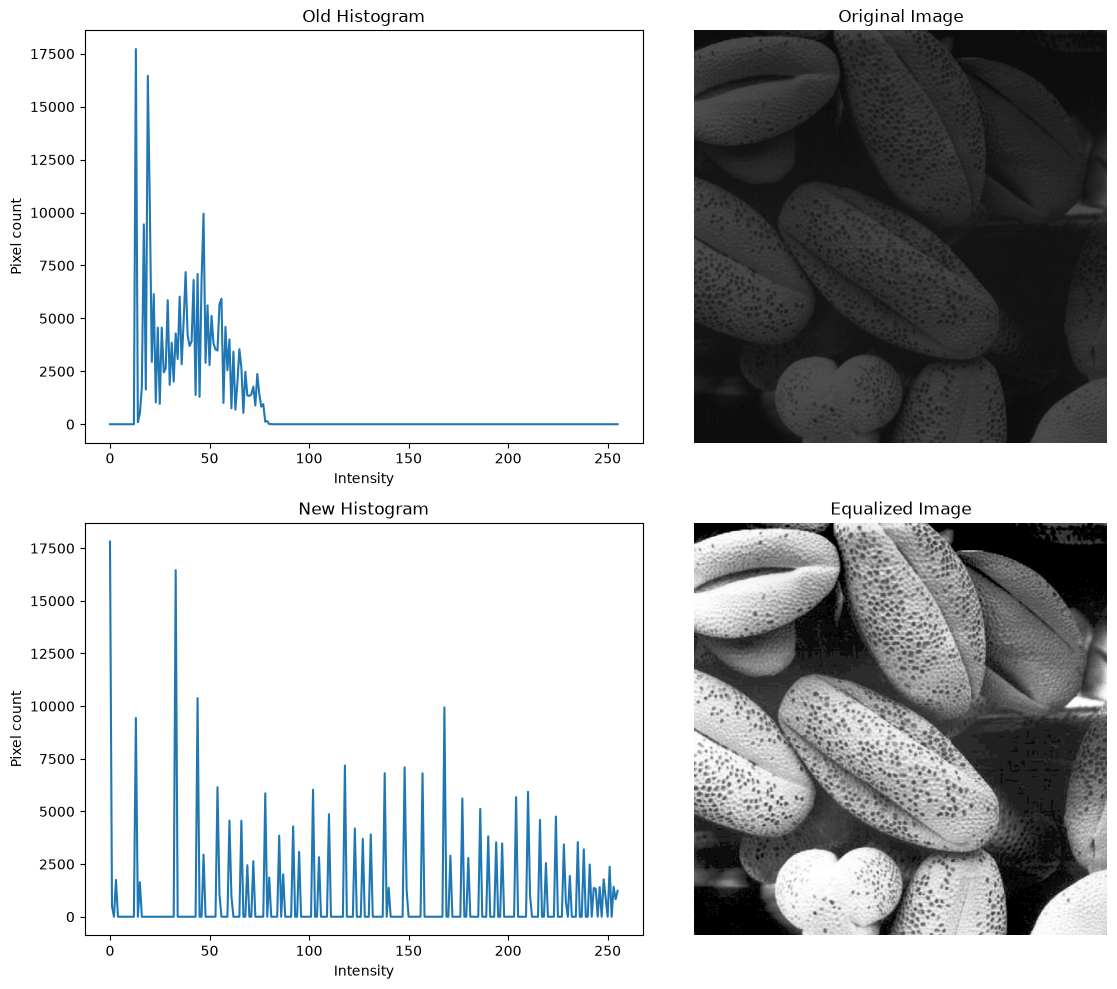

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(old_hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Old Histogram")

axes[0][1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(new_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("New Histogram")

axes[1][1].imshow(equalized_image, cmap='gray', vmin=0, vmax=255)
axes[1][1].axis('off')
axes[1][1].set_title("Equalized Image")

plt.tight_layout()
plt.show()

The function for histogram equalization was written according to standard practices, with
min-max normalizing. As in above implementations, a lookup table was used to map values.

Equalization formula = $\frac{cdf - cdf_{min}}{MN - cdf_{min}}*(L-1)$

The result was an image with brighter highlights, and darker shadows, with clear contrast instead of the same grayish look of the original.

# Question 6

In [62]:
im = cv.imread("images/q6.jpeg")
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
hue, saturation, value = cv.split(im_hsv)

Text(0.5, 1.0, 'Value')

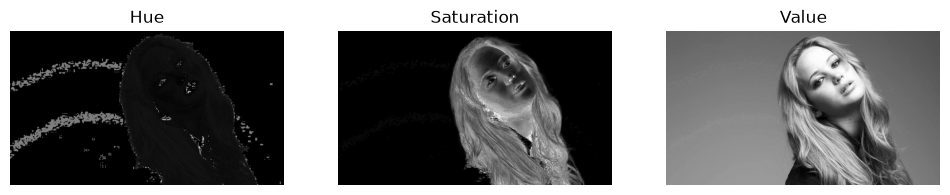

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(hue, cmap='gray', vmin=0, vmax=255)
axes[0].axis('off')
axes[0].set_title("Hue")

axes[1].imshow(saturation, cmap='gray', vmin=0, vmax=255)
axes[1].axis('off')
axes[1].set_title("Saturation")

axes[2].imshow(value, cmap='gray', vmin=0, vmax=255)
axes[2].axis('off')
axes[2].set_title("Value")

From the above planes, saturation was chosen to extract the foreground, because it has the most separation between the background and the foreground.

In [68]:
thresh_val = 13 # Threshold value was taken as 13 for better separation.
_, mask = cv.threshold(saturation, thresh_val, 255, cv.THRESH_BINARY) # Calculating mask

foreground = cv.bitwise_and(im, im, mask=mask)  #extract foreground
fore_hist = cv.calcHist([im], [0], mask, [256], [0,256]).flatten()  # Histogram
cdf = np.cumsum(fore_hist)      # Cumulative Sum of Histogram

In [80]:
MN = np.sum(fore_hist)
L = 256
lut = np.round((L-1) / MN * cdf).astype(np.uint8) # Normalization was not used since it was not available in slides.
equalized_foreground = cv.LUT(foreground, lut)
new_fore_hist = cv.calcHist([equalized_foreground], [0], mask, [256], [0,256]).flatten()
background = cv.bitwise_and(im, im, mask=cv.bitwise_not(mask))
final_result = cv.add(equalized_foreground, background)

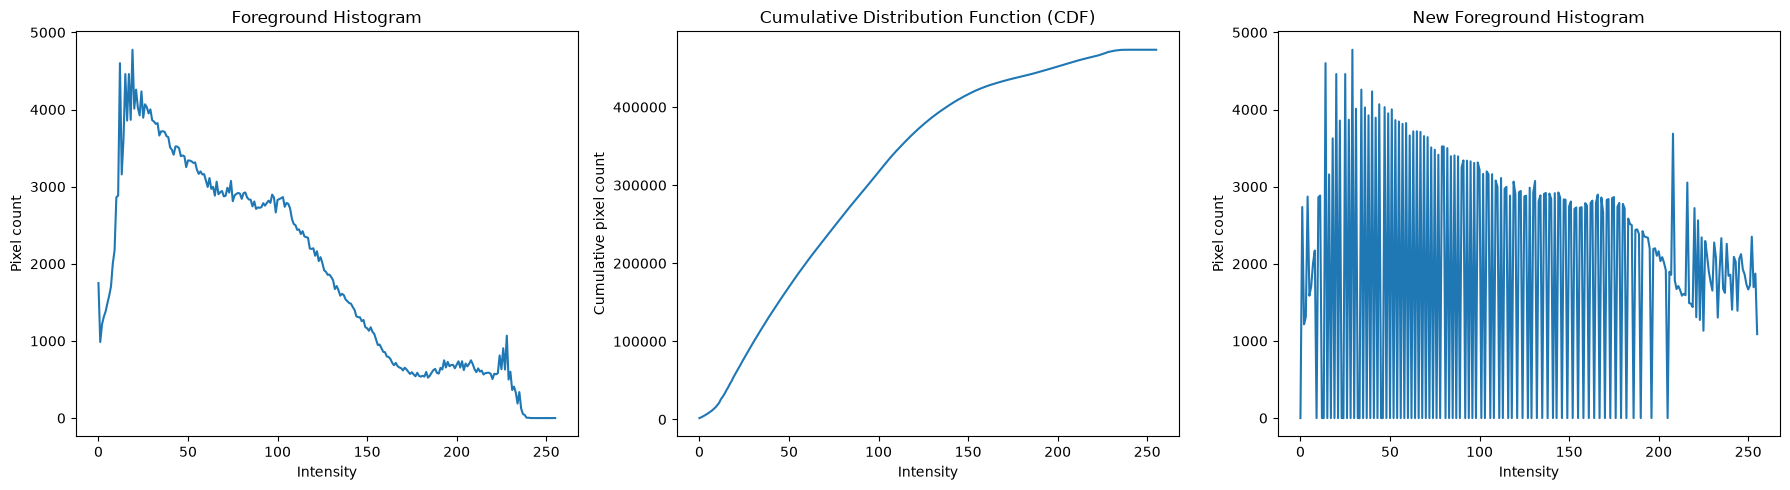

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fore_hist)
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("Foreground Histogram")

axes[1].plot(cdf)
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Cumulative pixel count")
axes[1].set_title("Cumulative Distribution Function (CDF)")

axes[2].plot(new_fore_hist)
axes[2].set_xlabel("Intensity")
axes[2].set_ylabel("Pixel count")
axes[2].set_title("New Foreground Histogram")

plt.tight_layout()
plt.show()

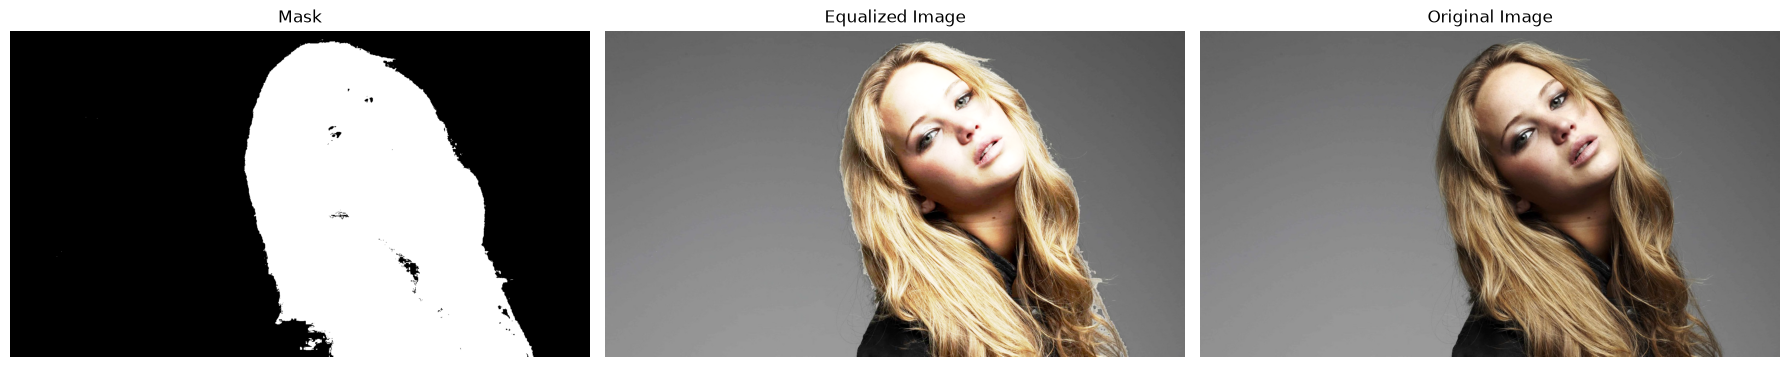

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
axes[0].axis('off')
axes[0].set_title("Mask")

axes[1].imshow(cv.cvtColor(final_result, cv.COLOR_BGR2RGB))
axes[1].axis('off')
axes[1].set_title("Equalized Image")

axes[2].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
axes[2].axis('off')
axes[2].set_title("Original Image")

plt.tight_layout()
plt.show()

# Question 7

# Question 8

# Question 9

# Question 10